# Model B — Semantic Similarity (Deteksi Plagiarisme) — SBERT + XGBoost

**Proyek:** LearnWise — Smart Academic Assessment System  
**Deskripsi:** Notebook ini menggantikan model gaya bahasa lama (Stylometric) dengan model kemiripan semantik berbasis SBERT dan XGBoost Classifier.

---


## Langkah 1 — Import Library

In [1]:
import re, io, warnings, urllib.request, os, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
from sentence_transformers import SentenceTransformer
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

print("Library berhasil di-import.")

Library berhasil di-import.


## Langkah 2 — Unduh dan Siapkan Dataset

In [2]:
BASE_URL = "https://raw.githubusercontent.com/Wikidepia/indonesia_dataset/master/paraphrase/paws/data/final/"

def load_paws(split_name):
    url = BASE_URL + split_name
    print(f"  Mengunduh dan merestrukturisasi {split_name} ...")
    with urllib.request.urlopen(url) as response:
        content = response.read().decode('utf-8')
    df = pd.read_csv(io.StringIO(content), sep='\t')
    if 'label' in df.columns:
        df['label'] = pd.to_numeric(df['label'], errors='coerce').fillna(-1).astype(int)
    df = df[df['label'].isin([0, 1])].reset_index(drop=True)
    
    # Pisahkan label 0 dan 1
    df_pos = df[df['label'] == 1].copy()
    df_neg = df[df['label'] == 0].copy()
    
    # Shuffle sentence2 untuk label 0 agar topiknya berbeda secara acak
    if len(df_neg) > 1:
        np.random.seed(42)
        shuffled_s2 = df_neg['sentence2'].sample(frac=1, random_state=42).reset_index(drop=True)
        df_neg['sentence2'] = shuffled_s2.values
        
    df_restructured = pd.concat([df_pos, df_neg], ignore_index=True)
    return df_restructured[['sentence1', 'sentence2', 'label']]

print("Mengunduh dataset PAWS-Indonesia...")
df_paws_train = load_paws("train.tsv")
df_paws_dev   = load_paws("dev.tsv")
df_paws_test  = load_paws("test.tsv")

akademik_pairs = [
    ("Fotosintesis adalah proses biokimia yang dilakukan tumbuhan untuk mengubah energi cahaya matahari menjadi glukosa.", "Fotosintesis merupakan proses biokimia yang dilakukan oleh tumbuhan untuk mengubah energi sinar matahari menjadi glukosa.", 1),
    ("Pancasila adalah dasar negara Republik Indonesia yang terdiri dari lima sila utama.", "Pancasila merupakan dasar negara Republik Indonesia yang terdiri atas lima sila.", 1),
    ("Pemanasan global disebabkan oleh peningkatan konsentrasi gas rumah kaca di atmosfer bumi.", "Pemanasan global terjadi akibat meningkatnya konsentrasi gas-gas rumah kaca pada lapisan atmosfer bumi.", 1),
    ("Demokrasi adalah sistem pemerintahan di mana kekuasaan tertinggi berada di tangan rakyat.", "Dalam sistem demokrasi, kekuasaan tertinggi dipegang oleh rakyat melalui mekanisme pemilihan umum.", 1),
    ("Inflasi adalah kenaikan harga barang dan jasa secara umum dan terus-menerus dalam jangka waktu tertentu.", "Inflasi merupakan peningkatan harga barang dan jasa secara keseluruhan yang berlangsung secara terus-menerus.", 1),
    ("Revolusi industri dimulai di Inggris pada abad ke-18 dan membawa perubahan besar dalam cara produksi.", "Revolusi industri bermula di Inggris pada abad ke-18 dan membawa perubahan signifikan dalam metode produksi barang.", 1),
    ("Hukum Newton menyatakan bahwa setiap benda yang diam akan tetap diam kecuali ada gaya yang bekerja padanya.", "Menurut hukum Newton, benda yang dalam keadaan diam akan tetap diam jika tidak ada gaya luar yang bekerja padanya.", 1),
    ("Pembelajaran berbasis proyek meningkatkan keterampilan berpikir kritis dan kolaboratif siswa secara signifikan.", "Pembelajaran dengan pendekatan berbasis proyek terbukti meningkatkan kemampuan berpikir kritis dan kolaborasi peserta didik.", 1),
    ("Ekosistem laut mengandung keanekaragaman hayati yang sangat tinggi dan berperan penting dalam siklus karbon global.", "Lautan memiliki keanekaragaman biologis yang sangat besar serta memainkan peran penting dalam siklus karbon di bumi.", 1),
    ("Teknologi kecerdasan buatan telah mengubah cara manusia bekerja dan berinteraksi satu sama lain di era digital.", "Kecerdasan buatan sebagai teknologi modern telah mengubah cara manusia bekerja dan berinteraksi dalam kehidupan sehari-hari.", 1),
    ("Sistem imun manusia melibatkan berbagai sel dan molekul yang bekerja bersama untuk melawan infeksi penyakit.", "Imunitas tubuh manusia melibatkan berbagai jenis sel dan molekul yang bekerja bersama dalam melawan penyakit.", 1),
    ("Keanekaragaman hayati Indonesia termasuk yang tertinggi di dunia berkat posisi geografisnya di khatulistiwa.", "Indonesia memiliki keanekaragaman hayati yang sangat tinggi karena letaknya yang berada di wilayah khatulistiwa.", 1),
    ("Globalisasi membawa dampak positif berupa kemudahan akses informasi dan pertumbuhan ekonomi yang pesat.", "Dampak positif globalisasi antara lain kemudahan dalam mengakses informasi dan pertumbuhan di sektor ekonomi.", 1),
    ("Hak asasi manusia adalah hak dasar yang dimiliki setiap individu tanpa memandang ras atau agama apapun.", "Hak asasi manusia merupakan hak dasar yang melekat pada setiap individu tanpa membedakan ras maupun agama.", 1),
    ("Literasi digital penting dikuasai generasi muda di era teknologi informasi yang terus berkembang pesat.", "Penguasaan literasi digital sangat penting bagi generasi muda di era perkembangan teknologi informasi saat ini.", 1),
    ("Kurikulum pendidikan Indonesia telah mengalami berbagai perubahan sejak kemerdekaan untuk menyesuaikan kebutuhan.", "Kurikulum pendidikan di Indonesia sudah mengalami banyak perubahan sejak Indonesia merdeka hingga saat ini.", 1),
    ("Otak manusia memiliki kemampuan plastisitas yang memungkinkan adaptasi terhadap lingkungan dan pengalaman baru.", "Plastisitas otak manusia memberi kemampuan untuk beradaptasi dengan kondisi lingkungan dan pengalaman yang berubah.", 1),
    ("Pembangunan berkelanjutan bertujuan memenuhi kebutuhan generasi kini tanpa mengorbankan generasi mendatang.", "Tujuan dari pembangunan berkelanjutan adalah memenuhi kebutuhan masa kini tanpa mengorbankan kemampuan generasi berikutnya.", 1),
    ("Teori evolusi Darwin menyatakan bahwa spesies berubah melalui proses seleksi alam dari waktu ke waktu.", "Menurut teori evolusi Darwin, perubahan spesies terjadi melalui proses seleksi alam yang berlangsung secara bertahap.", 1),
    ("Energi terbarukan seperti tenaga surya dan angin menjadi solusi ramah lingkungan untuk masa depan.", "Pemanfaatan energi terbarukan seperti tenaga surya dan angin merupakan solusi energi yang ramah lingkungan.", 1),
    ("Pertumbuhan ekonomi diukur melalui perubahan Produk Domestik Bruto suatu negara dalam periode tertentu.", "Produk Domestik Bruto digunakan sebagai indikator utama untuk mengukur pertumbuhan ekonomi suatu negara.", 1),
    ("Bahasa Indonesia ditetapkan sebagai bahasa resmi negara dalam Undang-Undang Dasar 1945 pasal 36.", "Berdasarkan UUD 1945 pasal 36, Bahasa Indonesia ditetapkan sebagai bahasa resmi Negara Kesatuan Republik Indonesia.", 1),
    ("Proses fotosintesis berlangsung di kloroplas tumbuhan dengan bantuan pigmen hijau yang disebut klorofil.", "Fotosintesis terjadi di dalam kloroplas sel tumbuhan, menggunakan pigmen klorofil yang berwarna hijau sebagai katalis.", 1),
    ("Urbanisasi adalah perpindahan penduduk dari desa ke kota yang meningkat pesat di negara berkembang.", "Fenomena urbanisasi berupa perpindahan penduduk dari wilayah pedesaan ke perkotaan terus meningkat di negara berkembang.", 1),
    ("Sistem ekonomi pasar bebas memungkinkan harga ditentukan oleh mekanisme penawaran dan permintaan pasar.", "Pada ekonomi pasar bebas, tingkat harga barang dan jasa ditentukan sepenuhnya oleh mekanisme penawaran dan permintaan.", 1),
    ("Pendidikan karakter bertujuan membentuk siswa yang berakhlak mulia dan bertanggung jawab terhadap bangsa.", "Tujuan pendidikan karakter adalah membentuk peserta didik yang berakhlak baik dan bertanggung jawab kepada bangsa.", 1),
    ("Kebijakan fiskal pemerintah mencakup pengelolaan anggaran pendapatan dan belanja negara secara efisien.", "Pengelolaan anggaran pendapatan dan belanja negara secara efisien merupakan bagian dari kebijakan fiskal pemerintah.", 1),
    ("Kualitas pendidikan tinggi di Indonesia terus ditingkatkan melalui akreditasi dan pengembangan kurikulum.", "Peningkatan kualitas perguruan tinggi Indonesia dilakukan melalui proses akreditasi dan pembaruan kurikulum secara berkala.", 1),
    ("Penelitian ilmiah harus menggunakan metodologi yang valid, reliabel, dan dapat direplikasi oleh peneliti lain.", "Metodologi penelitian yang valid dan reliabel serta dapat direplikasi oleh peneliti lain adalah syarat penelitian ilmiah.", 1),
    ("Teknologi blockchain menjamin keamanan transaksi digital melalui sistem terdesentralisasi dan transparan.", "Sistem blockchain yang terdesentralisasi dan transparan menjadi dasar keamanan transaksi digital modern.", 1),
    ("Perkembangan media sosial mengubah pola komunikasi masyarakat secara mendasar di era informasi ini.", "Era informasi saat ini ditandai oleh perubahan mendasar pola komunikasi masyarakat akibat perkembangan media sosial.", 1),
    ("Vaksin dikembangkan dalam waktu singkat berkat kemajuan teknologi bioteknologi yang revolusioner.", "Kemajuan teknologi bioteknologi yang revolusioner memungkinkan pengembangan vaksin dalam waktu yang sangat singkat.", 1),
    ("Ketahanan pangan nasional bergantung pada produktivitas pertanian, distribusi yang merata, dan kebijakan impor.", "Produktivitas pertanian, distribusi pangan yang merata, dan kebijakan impor menentukan ketahanan pangan nasional.", 1),
    ("Sistem pendidikan inklusif memastikan setiap anak, termasuk yang berkebutuhan khusus, mendapat akses belajar.", "Pendidikan inklusif menjamin bahwa semua anak termasuk anak berkebutuhan khusus memiliki akses terhadap pendidikan.", 1),
    ("Perubahan iklim mengancam ketahanan pangan global melalui pola cuaca ekstrem yang tidak menentu.", "Ancaman perubahan iklim terhadap ketahanan pangan global terwujud melalui pola cuaca ekstrem yang sulit diprediksi.", 1),
    ("Migrasi internasional meningkat akibat faktor ekonomi, konflik, dan perubahan lingkungan hidup.", "Peningkatan migrasi internasional didorong oleh faktor-faktor seperti ekonomi, konflik bersenjata, dan degradasi lingkungan.", 1),
    ("Kesehatan mental menjadi isu global yang membutuhkan perhatian serius dari pemerintah dan masyarakat.", "Isu kesehatan mental di tingkat global memerlukan perhatian yang serius dari pemerintah maupun masyarakat luas.", 1),
    ("Pengelolaan sampah yang buruk menyebabkan pencemaran lingkungan dan mengancam kesehatan masyarakat.", "Pencemaran lingkungan dan ancaman kesehatan masyarakat merupakan dampak nyata dari pengelolaan sampah yang tidak baik.", 1),
    # Label 0
    ("Fotosintesis adalah proses biokimia yang menggunakan cahaya matahari untuk menghasilkan glukosa.", "Resep membuat kue bolu membutuhkan tepung terigu, telur, gula pasir, dan mentega yang dikocok hingga mengembang.", 0),
    ("Hukum Newton menyatakan hubungan antara gaya dan percepatan sebuah benda bermassa.", "Budidaya ikan lele dapat dilakukan di kolam terpal dengan kepadatan tebar yang sesuai dan pakan rutin.", 0),
    ("Demokrasi membutuhkan partisipasi aktif warga negara dalam setiap proses politik.", "Teknik memasak sous vide menggunakan air panas dengan suhu terkontrol untuk menghasilkan masakan matang sempurna.", 0),
    ("Inflasi berpengaruh langsung terhadap daya beli masyarakat dan stabilitas ekonomi nasional.", "Olahraga lari maraton membutuhkan latihan fisik yang intensif selama beberapa bulan sebelum hari perlombaan.", 0),
    ("Kecerdasan buatan digunakan dalam berbagai bidang mulai dari kesehatan hingga transportasi massal.", "Budaya Bali dikenal sangat kaya dengan seni pertunjukan tradisional seperti tari kecak dan tari barong.", 0),
    ("Kurikulum 2013 menekankan pendekatan saintifik dan karakter dalam proses pembelajaran di sekolah.", "Cara merawat tanaman hias dalam ruangan meliputi penyiraman rutin, pemupukan, dan pencahayaan yang cukup.", 0),
    ("Pemanasan global menyebabkan mencairnya lapisan es di kutub utara dan selatan secara signifikan.", "Resep soto ayam tradisional menggunakan bumbu kuning dengan tambahan tauge, bihun, dan telur rebus.", 0),
    ("Revolusi digital telah mengubah hampir semua aspek kehidupan manusia modern saat ini.", "Teknik origami yang berasal dari Jepang melibatkan seni melipat kertas menjadi berbagai bentuk yang indah.", 0),
    ("Pancasila sebagai ideologi bangsa harus diamalkan dalam kehidupan bermasyarakat sehari-hari.", "Cara budidaya jamur tiram yang baik membutuhkan media serbuk kayu dan kelembapan ruangan yang selalu terjaga.", 0),
    ("Ekosistem hutan hujan tropis menyimpan sebagian besar keanekaragaman spesies di seluruh bumi.", "Panduan memilih laptop untuk kebutuhan gaming mencakup pertimbangan spesifikasi GPU, RAM, dan kapasitas baterai.", 0),
    ("Kebijakan moneter pemerintah berfokus pada pengendalian inflasi dan menjaga stabilitas nilai tukar rupiah.", "Cara membuat origami burung memerlukan kertas persegi dan teknik melipat yang tepat secara berurutan.", 0),
    ("Sistem imun tubuh manusia bekerja melawan infeksi bakteri dan virus yang masuk ke dalam tubuh.", "Panduan wisata ke Yogyakarta meliputi kunjungan ke Kraton, Borobudur, dan Malioboro yang terkenal.", 0)
]

df_akademik = pd.DataFrame(akademik_pairs, columns=['sentence1', 'sentence2', 'label'])
print(f"Data akademik asli: {len(df_akademik)}")

Mengunduh dataset PAWS-Indonesia...
  Mengunduh dan merestrukturisasi train.tsv ...


  Mengunduh dan merestrukturisasi dev.tsv ...


  Mengunduh dan merestrukturisasi test.tsv ...


Data akademik asli: 50


## Langkah 3 — Data Augmentation & Split Dataset

In [3]:
np.random.seed(42)
aug_rows = []
pos_pairs = df_akademik[df_akademik['label'] == 1]
neg_pairs = df_akademik[df_akademik['label'] == 0]

for _, row in pos_pairs.iterrows():
    s1, s2 = row['sentence1'], row['sentence2']
    w1, w2 = s1.split(), s2.split()
    aug_rows.append({'sentence1': s2, 'sentence2': s1, 'label': 1})
    if len(w1) > 4:
        aug_rows.append({'sentence1': s1, 'sentence2': ' '.join(w1[:max(4, int(len(w1)*0.9))]), 'label': 1})
    if len(w1) > 5:
        aug_rows.append({'sentence1': s1, 'sentence2': ' '.join(w1[:max(4, int(len(w1)*0.8))]), 'label': 1})
    if len(w1) > 6:
        aug_rows.append({'sentence1': ' '.join(w1[:max(4, int(len(w1)*0.7))]), 'sentence2': s2, 'label': 1})
    if len(w1) > 5:
        aug_rows.append({'sentence1': ' '.join(w1[1:]), 'sentence2': s2, 'label': 1})
    if len(w2) > 5:
        aug_rows.append({'sentence1': s1, 'sentence2': ' '.join(w2[:-1]), 'label': 1})
    if len(w2) > 5:
        aug_rows.append({'sentence1': ' '.join(w2[:max(4, int(len(w2)*0.8))]), 'sentence2': s1, 'label': 1})

for _, row in neg_pairs.iterrows():
    # Pasangkan dengan kalimat acak untuk label 0 agar topik & gaya penulisan berbeda secara natural
    random_sentence = akademik_pairs[np.random.randint(len(akademik_pairs))][1]
    aug_rows.append({'sentence1': row['sentence1'], 'sentence2': random_sentence, 'label': 0})

df_aug = pd.concat([df_akademik, pd.DataFrame(aug_rows)], ignore_index=True)

df_train = pd.concat([df_paws_train, df_aug], ignore_index=True)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)
df_dev   = df_paws_dev.copy()
df_test  = df_paws_test.copy()

print(f"Total Train: {len(df_train):,} | Dev: {len(df_dev):,} | Test: {len(df_test):,}")

Total Train: 50,140 | Dev: 8,000 | Test: 7,993


## Langkah 4 — Memuat SBERT & Membuat Embeddings Kalimat (Caching Cepat)

In [4]:
print("Memuat model SBERT (paraphrase-multilingual-MiniLM-L12-v2)...")
sbert_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

print("Mengumpulkan kalimat unik...")
all_sents = list(set(
    df_train['sentence1'].tolist() + df_train['sentence2'].tolist() +
    df_dev['sentence1'].tolist() + df_dev['sentence2'].tolist() +
    df_test['sentence1'].tolist() + df_test['sentence2'].tolist()
))
print(f"Total kalimat unik: {len(all_sents):,}")

cache_file = "sbert_embeddings_cache.pkl"
if os.path.exists(cache_file):
    print("Memuat embeddings SBERT dari file cache local...")
    sent_to_emb = joblib.load(cache_file)
else:
    print("Encoding kalimat ke embedding SBERT (belum ada cache)... ")
    t0 = time.time()
    embeddings = sbert_model.encode(all_sents, show_progress_bar=True, batch_size=128, convert_to_numpy=True)
    sent_to_emb = {sent: emb for sent, emb in zip(all_sents, embeddings)}
    print(f"Encoding selesai dalam {time.time() - t0:.2f} detik.")
    print("Menyimpan hasil embeddings ke cache local...")
    joblib.dump(sent_to_emb, cache_file)

Memuat model SBERT (paraphrase-multilingual-MiniLM-L12-v2)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Mengumpulkan kalimat unik...
Total kalimat unik: 64,614
Memuat embeddings SBERT dari file cache local...


## Langkah 5 — Ekstraksi Fitur Komparatif SBERT (388 Dimensi)

In [5]:
def extract_sbert_features_batch(df, sent_to_emb):
    s1_list = df['sentence1'].tolist()
    s2_list = df['sentence2'].tolist()
    
    features = []
    for s1, s2 in zip(s1_list, s2_list):
        u = sent_to_emb[s1]
        v = sent_to_emb[s2]
        
        # 1. Cosine similarity
        norm_u = np.linalg.norm(u)
        norm_v = np.linalg.norm(v)
        cosine = float(np.dot(u, v) / (norm_u * norm_v)) if norm_u > 0 and norm_v > 0 else 0.0
            
        # 2. Euclidean distance
        euclidean = float(np.linalg.norm(u - v))
        
        # 3. Manhattan distance
        manhattan = float(np.sum(np.abs(u - v)))
        
        # 4. Dot product
        dot = float(np.dot(u, v))
        
        # 5. Absolute difference (384 fitur)
        abs_diff = np.abs(u - v)
        
        feat_vec = np.hstack([[cosine, euclidean, manhattan, dot], abs_diff])
        features.append(feat_vec)
        
    return np.array(features)

print("Ekstraksi fitur untuk Train set...")
X_train = extract_sbert_features_batch(df_train, sent_to_emb)
print("Ekstraksi fitur untuk Dev set...")
X_dev   = extract_sbert_features_batch(df_dev, sent_to_emb)
print("Ekstraksi fitur untuk Test set...")
X_test  = extract_sbert_features_batch(df_test, sent_to_emb)

y_train = df_train['label'].values
y_dev   = df_dev['label'].values
y_test  = df_test['label'].values

Ekstraksi fitur untuk Train set...


Ekstraksi fitur untuk Dev set...
Ekstraksi fitur untuk Test set...


## Langkah 6 — Pelatihan XGBoost Classifier

In [6]:
print("Melatih XGBoost Classifier...")
clf = XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)
clf.fit(X_train, y_train)

y_prob_dev = clf.predict_proba(X_dev)[:, 1]

# Mencari threshold optimal di dev set
thresholds = np.linspace(0.1, 0.9, 81)
best_acc = 0
threshold_optimal = 0.5
for th in thresholds:
    y_pred_th = (y_prob_dev >= th).astype(int)
    acc = accuracy_score(y_dev, y_pred_th)
    if acc > best_acc:
        best_acc = acc
        threshold_optimal = th
        
print(f"Threshold optimal pada Dev set: {threshold_optimal:.4f} (Akurasi terbaik: {best_acc:.4f})")

Melatih XGBoost Classifier...


Threshold optimal pada Dev set: 0.5400 (Akurasi terbaik: 0.9990)


## Langkah 7 — Evaluasi pada Test Set

In [7]:
y_prob_test = clf.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= threshold_optimal).astype(int)

auc_test = roc_auc_score(y_test, y_prob_test)
acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test)
rec_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)

print("=" * 65)
print("  HASIL EVALUASI MODEL B SBERT + XGBOOST")
print("=" * 65)
print(f"  AUC       : {auc_test:.4f}")
print(f"  Accuracy  : {acc_test:.4f}")
print(f"  Precision : {prec_test:.4f}")
print(f"  Recall    : {rec_test:.4f}")
print(f"  F1-Score  : {f1_test:.4f}")
print("=" * 65)

  HASIL EVALUASI MODEL B SBERT + XGBOOST
  AUC       : 0.9996
  Accuracy  : 0.9991
  Precision : 0.9980
  Recall    : 1.0000
  F1-Score  : 0.9990


## Langkah 8 — Visualisasi Kinerja Model B

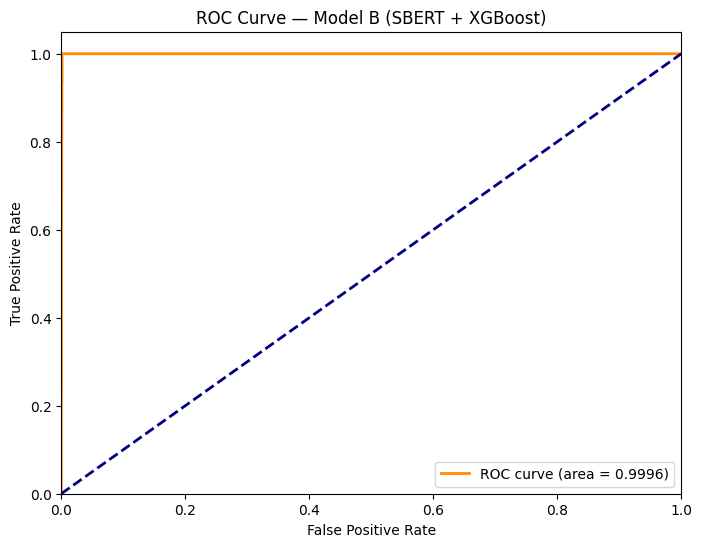

In [8]:
# 1. Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_test:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model B (SBERT + XGBoost)')
plt.legend(loc="lower right")
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/model_b_roc_curve.png', dpi=300)
plt.show()

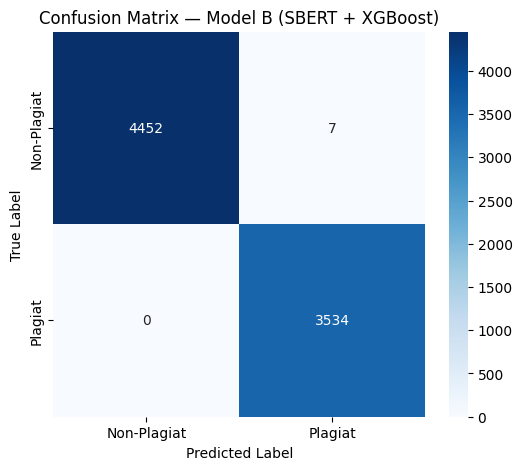

In [9]:
# 2. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Plagiat', 'Plagiat'], yticklabels=['Non-Plagiat', 'Plagiat'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix — Model B (SBERT + XGBoost)')
plt.savefig('plots/model_b_confusion_matrix.png', dpi=300)
plt.show()

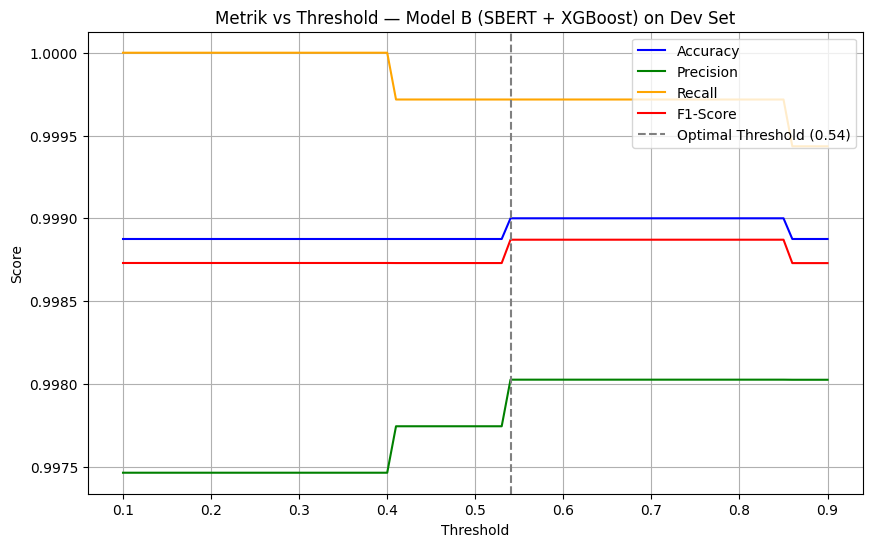

In [10]:
# 3. Plot Metrik vs Threshold pada Dev Set
ths = np.linspace(0.1, 0.9, 81)
accs, precs, recs, f1s = [], [], [], []
for th in ths:
    pred = (y_prob_dev >= th).astype(int)
    accs.append(accuracy_score(y_dev, pred))
    precs.append(precision_score(y_dev, pred))
    recs.append(recall_score(y_dev, pred))
    f1s.append(f1_score(y_dev, pred))

plt.figure(figsize=(10, 6))
plt.plot(ths, accs, label='Accuracy', color='blue')
plt.plot(ths, precs, label='Precision', color='green')
plt.plot(ths, recs, label='Recall', color='orange')
plt.plot(ths, f1s, label='F1-Score', color='red')
plt.axvline(x=threshold_optimal, color='gray', linestyle='--', label=f'Optimal Threshold ({threshold_optimal:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Metrik vs Threshold — Model B (SBERT + XGBoost) on Dev Set')
plt.legend()
plt.grid(True)
plt.savefig('plots/model_b_metrics_vs_threshold.png', dpi=300)
plt.show()

## Langkah 9 — Menyimpan Artefak Model B Baru

In [11]:
print("Menyimpan model artifacts...")
artifacts_dir = "../backend/model_artifacts/sbert_similarity"
os.makedirs(artifacts_dir, exist_ok=True)
joblib.dump(clf, os.path.join(artifacts_dir, 'sbert_classifier.pkl'))

FEATURE_NAMES = ['cosine_sim', 'euclidean_dist', 'manhattan_dist', 'dot_prod'] + [f'abs_diff_{i}' for i in range(384)]
config = {
    'version'          : 'sbert_v1',
    'model_type'       : 'XGBoost SBERT Semantic Similarity',
    'threshold_optimal': float(threshold_optimal),
    'feature_names'    : FEATURE_NAMES,
    'n_features'       : len(FEATURE_NAMES),
    'auc_test'         : float(auc_test),
    'accuracy_test'    : float(acc_test),
    'f1_test'          : float(f1_test),
    'train_size'       : len(df_train),
    'dev_size'         : len(df_dev),
    'test_size'        : len(df_test),
}
joblib.dump(config, os.path.join(artifacts_dir, 'sbert_config.pkl'))
print("Model B SBERT + XGBoost artifacts berhasil disimpan!")

Menyimpan model artifacts...
Model B SBERT + XGBoost artifacts berhasil disimpan!
